# Optimizer Stress Test Report
## Deterministic Sanity + Edge + Stochastic Stress

| Section | Cases | Purpose |
|---|---|---|
| 1. Sanity cases | 5 | Hand-crafted single-scenario price/gen profiles with analytically known optimal decisions |
| 2. Edge cases | 8 | Boundary conditions: zero / negative prices, break-even thresholds, SOC limits, alternating extremes |
| 3. **Stochastic stress (new)** | 6 | Multi-scenario tests for non-anticipativity, recourse feasibility, true VSS, CVaR, cycle cap, DA-ID basis |

BESS configuration: **40 MW / 80 MWh** (Horns Rev 1, 25 % plant capacity).

RTE = 0.9025, deg = 10 €/MWh, SOC range = [8, 72] MWh (init = 40 MWh).

All cases must PASS to validate that the MILP responds correctly to both deterministic and stochastic inputs across edge regimes.

---


<a id="sanity"></a>
## 1. Sanity Cases (Deterministic, Single Scenario)

Runs `sanity_cases.run_and_report()` and renders the verdict block + per-hour table.

In [1]:
import os, sys
from pathlib import Path

# Always resolve repo root robustly so the notebook runs whether kernel cwd is
# the repo root or the tests/ folder.
def _repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'tests' / 'sanity_cases.py').exists() and (p / 'src').exists():
            return p
    raise RuntimeError(f'Cannot resolve repo root from {Path.cwd()}')

REPO = _repo_root()
os.chdir(REPO)                                             # tests load config via relative path
for p in (REPO / 'src', REPO / 'tests'):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import numpy as np
import matplotlib.pyplot as plt
from sanity_cases import run_and_report as run_sanity
print("Running sanity cases...")
sanity_md = run_sanity(output_path=None)
print(f"Done ({sanity_md.count('PASS')} PASS, {sanity_md.count('FAIL')} FAIL markers in output)")


Running sanity cases...
  Running case_1_two_block... 

PASS
  Running case_2_single_spike... 

PASS
  Running case_3_negative_prices... 

PASS
  Running case_4_flat_prices... 

PASS
  Running case_5_renewable_storage... 

PASS
Done (11 PASS, 0 FAIL markers in output)


In [2]:
from IPython.display import Markdown
Markdown(sanity_md)


# Optimizer Sanity Cases — Deterministic Single-Scenario Tests

Run date: 2026-05-13  |  Solver: HiGHS

BESS: Power: 40.0 MW / 40.0 MW  |  Capacity: 80.0 MWh  |  SOC init/min/max: 40.0/8.0/72.0 MWh  |  η_ch=0.95 η_dis=0.95 RTE=0.9025  |  Deg: 10.0 €/MWh

Break-even: p_high · RTE ≥ p_low + c_deg · (1 + RTE)  → at p_low=30: p_high must exceed 54.3 €/MWh.

> **Note on q_da vs net position:** when DA price = ID price the solver is indifferent
> about how to split a position between the two legs. All checks use the **total net
> position = q_da + q_id** or physical variables (p_ch, p_dis, SOC), never q_da alone.

---

## Case 1 — Two-block: morning cheap / evening expensive

**Description:** DA = 30 €/MWh h0-11 / 150 €/MWh h12-23. No generation.

**Expected:** Charge in morning (net ≤ 0), discharge in evening (net ≥ 0).

**Profit:** €2908.63  |  **Solve time:** 0.460s  |  **Status:** optimal

**Real-world context:** The optimizer submits a buy bid (negative net position) for cheap morning hours and a sell bid for the expensive evening, locked in by 12:00 CET the day before delivery. In DK1 this pattern matches buying overnight wind surplus and selling into the evening demand peak. The €72.72 profit for a 1 MW/2 MWh battery is the textbook price-spread arbitrage revenue stream for grid-scale BESS.

### Checks

  ✓ Charging occurs in morning (h0-11) — Σ p_ch[0:12] = 33.684 MWh
  ✓ No discharging in morning (h0-11) — Σ p_dis[0:12] = 0.0000 MWh
  ✓ Discharging occurs in evening (h12-23) — Σ p_dis[12:] = 30.400 MWh
  ✓ No charging in evening (h12-23) — Σ p_ch[12:] = 0.0000 MWh
  ✓ Net position ≤ 0 in morning (buying / idle) — max net[0:12] = 0.0000 MW
  ✓ Net position ≥ 0 in evening (selling / idle) — min net[12:] = 0.0000 MW
  ✓ SOC peaks after morning charge — SOC_peak = 72.000 MWh
  ✓ Expected profit > 0 — profit = €2908.63
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    1 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    2 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    3 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    4 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    5 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    6 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    7 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    8 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    9 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   10 |     30.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   11 |     30.0 |      -33.684 | 33.684 | 0.000 | 40.000 | CHARGE |
|   12 |    150.0 |      +30.400 | 0.000 | 30.400 | 72.000 | DISCHARGE |
|   13 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   14 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   15 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   16 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   17 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   18 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   19 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   20 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   21 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   22 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   23 |    150.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |

---

## Case 2 — Single price spike at hour 22

**Description:** DA = 50 €/MWh all hours, h22 = 500 €/MWh. No generation.

**Expected:** Pre-charge before h22, full discharge at h22.

**Profit:** €16940.72  |  **Solve time:** 0.109s  |  **Status:** optimal

**Real-world context:** A price spike at h22 (21:00–22:00 UTC) could reflect a large plant outage or an unexpected cold snap. The optimizer pre-charges during flat hours (50 €/MWh) and fires a full sell bid into the 500 €/MWh clearing price. This 'peak-shaving arbitrage' is also the economic foundation for capacity market bids: the battery guarantees availability at the exact hour the system is stressed, which is worth far more than average-price arbitrage. Operators with balancing market access (FCR/mFRR) can layer ancillary service revenue on top of the same position.

### Checks

  ✓ Pre-charging before h22 — Σ p_ch[0:22] = 33.684 MWh
  ✓ SOC at spike hour is above SOC_INIT (pre-loaded) — SOC[22] = 72.000 MWh (init=40.0)
  ✓ Discharging at spike hour h22 — p_dis[22] = 40.000 MW
  ✓ Not charging at spike hour — p_ch[22] = 0.0000 MW
  ✓ Net position at h22 ≥ 0 (selling) — net[22] = 40.000 MW
  ✓ Expected profit > 0 — profit = €16940.72
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    1 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    2 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    3 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    4 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|    5 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|    6 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    7 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    8 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|    9 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   10 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   11 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   12 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   13 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   14 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   15 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   16 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   17 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   18 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   19 |     50.0 |       +0.000 | -0.000 | 0.000 | 40.000 | idle |
|   20 |     50.0 |      -33.684 | 33.684 | 0.000 | 40.000 | CHARGE |
|   21 |     50.0 |       +0.000 | 0.000 | 0.000 | 72.000 | idle |
|   22 |    500.0 |      +40.000 | 0.000 | 40.000 | 72.000 | DISCHARGE |
|   23 |     50.0 |      -10.637 | 10.637 | 0.000 | 29.895 | CHARGE |

---

## Case 3 — Negative price window (hours 0-5)

**Description:** DA = −200 €/MWh h0-5, +80 €/MWh h6-23. No generation.

**Expected:** Buy (charge) during negative hours; sell or idle during positive.

**Profit:** €8568.05  |  **Solve time:** 0.129s  |  **Status:** optimal

**Real-world context:** Negative prices occur in the Nordic pool during storm events when wind is high and demand is low. Energinet allows prices down to −500 €/MWh. At negative prices, market participants get PAID to consume power, so the optimizer submits a negative-priced buy bid to charge the battery — turning a curtailment penalty into revenue. After h6 prices turn positive (80 €/MWh), stored energy is sold. This is the primary economic rationale for co-locating battery storage with offshore wind: negative-price hours that would otherwise represent a cost become a charging opportunity.

### Checks

  ✓ Charging occurs during negative-price hours (h0-5) — Σ p_ch[0:6] = 118.006 MWh
  ✓ Net consumption > net production during h0-5 (more buying than selling) — Σ p_ch[0:6]=118.006 > Σ p_dis[0:6]=76.100 MWh
  ✓ No charging at positive prices (h6-23) — unprofitable — Σ p_ch[6:] = 0.0000 MWh
  ✓ Net position ≥ 0 at positive-price hours (selling or idle) — min net[6:] = 0.0000 MW
  ✓ Expected profit > 0 — profit = €8568.05
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |   -200.0 |      -10.637 | 10.637 | 0.000 | 40.000 | CHARGE |
|    1 |   -200.0 |      +40.000 | 0.000 | 40.000 | 50.105 | DISCHARGE |
|    2 |   -200.0 |      -27.368 | 27.368 | 0.000 | 8.000 | CHARGE |
|    3 |   -200.0 |      -40.000 | 40.000 | 0.000 | 34.000 | CHARGE |
|    4 |   -200.0 |      +36.100 | 0.000 | 36.100 | 72.000 | DISCHARGE |
|    5 |   -200.0 |      -40.000 | 40.000 | 0.000 | 34.000 | CHARGE |
|    6 |     80.0 |      +30.400 | 0.000 | 30.400 | 72.000 | DISCHARGE |
|    7 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    8 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    9 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   10 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   11 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   12 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   13 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   14 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   15 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   16 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   17 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   18 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   19 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   20 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   21 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   22 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   23 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |

---

## Case 4 — Flat prices (no arbitrage)

**Description:** DA = 80 €/MWh all 24 hours. No generation.

**Expected:** Battery fully idle — arbitrage at flat prices loses money (RTE + deg cost).

**Profit:** €0.00  |  **Solve time:** 0.124s  |  **Status:** optimal

**Real-world context:** On a mild autumn day with steady industrial load and moderate wind, DA prices may barely move across 24 hours. The optimizer submits zero-volume storage bids for every hour. This is the correct 'do nothing' baseline: any cycling incurs degradation cost (10 €/MWh) with zero offsetting revenue from a flat price profile. A naive rule-of-thumb strategy ('always cycle when price > 0') would destroy value here. In real markets, flat-price days are also opportunities to accumulate FCR-N ancillary service revenue by holding the battery at 50 % SOC without committing to any energy position.

### Checks

  ✓ Total throughput ≈ 0 (no trading) — throughput = 0.000000 MWh
  ✓ All p_ch ≈ 0 — max p_ch = 0.000000 MW
  ✓ All p_dis ≈ 0 — max p_dis = 0.000000 MW
  ✓ Total net position ≈ 0 (no open position) — max |net| = 0.000000 MW
  ✓ Expected profit ≈ 0 — profit = €0.0000
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    1 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    2 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    3 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    4 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    5 |     80.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    6 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    7 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    8 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    9 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   10 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   11 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   12 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   13 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   14 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   15 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   16 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   17 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   18 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   19 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   20 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   21 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   22 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   23 |     80.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |

---

## Case 5 — Renewable storage: wind morning / calm evening

**Description:** Gen = 2 MW h0-11 / 0 MW h12-23. DA = 40 €/MWh morning / 130 €/MWh evening.

**Expected:** Charge from excess wind (morning), discharge into expensive evening.

**Profit:** €2923.79  |  **Solve time:** 0.143s  |  **Status:** optimal

**Real-world context:** The optimizer co-optimises the wind generation schedule and battery dispatch. During windy morning hours (40 €/MWh, gen = 2 MW), it charges the battery rather than selling all wind at a depressed price — the DA bid shows a reduced net position (less wind sold than available). In the calm, expensive evening (130 €/MWh, gen = 0), it discharges stored energy into the market. This wind-plus-storage co-optimisation is the commercial model behind offshore wind projects with embedded storage corridors and is why a standalone wind plant always earns less than a co-located wind+battery system.

### Checks

  ✓ Charging during wind morning (h0-11) — Σ p_ch[0:12] = 33.684 MWh
  ✓ No discharging during wind morning (h0-11) — Σ p_dis[0:12] = 0.0000 MWh
  ✓ Discharging during calm evening (h12-23) — Σ p_dis[12:] = 30.400 MWh
  ✓ At least one morning hour absorbs wind (min net < gen) — min net[0:12] = -31.684 MW (gen=2)
  ✓ Evening net position > 0 (selling stored energy) — max net[12:] = 30.400 MW
  ✓ SOC peaks above SOC_INIT (energy was stored) — SOC_peak = 72.000 MWh
  ✓ Expected profit > 0 — profit = €2923.79
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    1 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    2 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    3 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    4 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    5 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    6 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    7 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    8 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|    9 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|   10 |     40.0 |       +2.000 | 0.000 | -0.000 | 40.000 | idle gen=2.0 |
|   11 |     40.0 |      -31.684 | 33.684 | 0.000 | 40.000 | CHARGE gen=2.0 |
|   12 |    130.0 |      +30.400 | 0.000 | 30.400 | 72.000 | DISCHARGE |
|   13 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   14 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   15 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   16 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   17 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   18 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   19 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   20 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   21 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   22 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   23 |    130.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |

---


## Summary

| Case | Profit | Status |
|------|--------|--------|
| Case 1 — Two-block: morning cheap / evening expensive | €2908.63 | PASS ✓ |
| Case 2 — Single price spike at hour 22 | €16940.72 | PASS ✓ |
| Case 3 — Negative price window (hours 0-5) | €8568.05 | PASS ✓ |
| Case 4 — Flat prices (no arbitrage) | €0.00 | PASS ✓ |
| Case 5 — Renewable storage: wind morning / calm evening | €2923.79 | PASS ✓ |


**All cases PASSED ✓**


<a id="edge"></a>
## 2. Edge Cases (Deterministic, Single Scenario)

In [3]:
from edge_cases import run_and_report as run_edge
print("Running edge cases...")
edge_md = run_edge(output_path=None)
print(f"Done ({edge_md.count('PASS')} PASS, {edge_md.count('FAIL')} FAIL markers in output)")


Running edge cases...
  Running case_1_zero_prices... 

PASS


  Running case_2_neg100_above_breakeven... 

PASS
  Running case_3_neg300_below_breakeven... 

PASS
  Running case_4_spread_just_below_breakeven... 

PASS
  Running case_5_spread_just_above_breakeven... 

PASS
  Running case_6_alternating_prices... 

PASS
  Running case_7_soc_min_start... 

PASS
  Running case_8_soc_max_start... 

PASS
Done (17 PASS, 0 FAIL markers in output)


In [4]:
Markdown(edge_md)


# Optimizer Edge Cases — Boundary Conditions & Break-Even Tests

Run date: 2026-05-13  |  Solver: HiGHS

BESS: Power: 40.0 MW / 40.0 MW  |  Capacity: 80.0 MWh  |  SOC init/min/max: 40.0/8.0/72.0 MWh  |  η_ch=0.95 η_dis=0.95 RTE=0.9025  |  Deg: 10.0 €/MWh

Break-even thresholds: uniform_neg=195.1 €/MWh  |  two-block (p_low=50) p_high_be=76.48 €/MWh

> **Note on q_da vs net position:** when DA price = ID price the solver is indifferent
> about how to split a position between the two legs. All checks use the **total net
> position = q_da + q_id** or physical variables (p_ch, p_dis, SOC), never q_da alone.

---

## Edge 1 — All prices = 0 (no revenue)

**Description:** DA = 0 €/MWh all 24 hours. No generation.

**Expected:** Battery fully idle — any throughput incurs degradation with zero revenue.

**Profit:** €0.00  |  **Solve time:** 0.170s  |  **Status:** optimal

**Real-world context:** Zero clearing prices occur during extreme renewable surplus meeting very low demand (e.g., Easter Sunday in Denmark during a wind storm). With no price signal in either direction, there is no economic case for storage dispatch. The battery sits idle to avoid degradation cost for zero gain. In practice, operators in this situation shift focus to ancillary services (FCR-N, FCR-D) which pay a capacity fee independent of energy prices.

### Checks

  ✓ All p_ch = 0 — max p_ch = 0.000000 MW
  ✓ All p_dis = 0 — max p_dis = 0.000000 MW
  ✓ Total throughput = 0 — throughput = 0.000000 MWh
  ✓ Net position = 0 — max |net| = 0.000000 MW
  ✓ Expected profit = 0 — profit = €0.0000
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    1 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    2 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    3 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    4 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    5 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    6 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    7 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    8 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    9 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   10 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   11 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   12 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   13 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   14 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   15 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   16 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   17 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   18 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   19 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   20 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   21 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   22 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   23 |      0.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |

---

## Edge 2 — Uniform −100 €/MWh + 2 MW wind (forced selling, loss)

**Description:** DA = −100 €/MWh, gen = 2 MW all 24 hours. |p|=100 < P_BE=195.1. No curtailment.

**Expected:** Battery idle (cycling unprofitable), all generation sold at loss. Profit ≈ −€4800.

**Profit:** €-4800.00  |  **Solve time:** 0.098s  |  **Status:** optimal

**Real-world context:** Negative clearing prices are a real feature of the Nordic day-ahead market (EPEX Spot Nord Pool). At −100 €/MWh, an offshore wind plant owes the grid operator €100 per MWh it injects — a €4,800 bill for a 48 MWh day. Unlike gas plants, offshore turbines cannot be shut down quickly (minimum 4–6 hours notice, electrical safety constraints, PPA obligations). The battery cannot mitigate this: cycling is upside-down below the 195 €/MWh break-even. The real-world response is to either accept the loss or negotiate a negative-price suspension clause in the PPA that halts delivery obligations during sustained negative price windows.

### Checks

  ✓ Battery idle — cycling below break-even makes losses worse — throughput = -0.000000 MWh
  ✓ All generation forced to market (energy balance equality, no curtailment) — max |net − 2| = 0.0000 MW
  ✓ Profit ≈ −4800 € (2 MW × 24h × −100 €/MWh, no battery benefit) — profit = €-4800.00 (expected ≈ €-4800)
  ✓ Profit < 0 — negative prices with non-curtailable generation — profit = €-4800.00
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    1 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    2 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    3 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    4 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    5 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    6 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    7 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    8 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|    9 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   10 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   11 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   12 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   13 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   14 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   15 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   16 |   -100.0 |       +2.000 | -0.000 | 0.000 | 40.000 | idle |
|   17 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   18 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   19 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   20 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   21 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   22 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |
|   23 |   -100.0 |       +2.000 | 0.000 | 0.000 | 40.000 | idle |

---

## Edge 3 — Uniform −300 €/MWh + 2 MW wind (cycling reduces losses)

**Description:** DA = −300 €/MWh, gen = 2 MW all 24 hours. |p|=300 > P_BE=195.1. No curtailment.

**Expected:** Battery cycles (profitable above break-even), but generation losses dominate. Profit < 0.

**Profit:** €-9414.96  |  **Solve time:** 0.966s  |  **Status:** optimal

**Real-world context:** Extreme negative prices (−300 €/MWh) occur during severe curtailment events — record wind output on a public holiday is a real example. At this level, battery cycling is profitable in isolation (|p| > 195 €/MWh break-even saves ~€125/day) but the unavoidable generation selling dominates: the plant is still €14,275 in the red. Events like this drive investment in demand-response partnerships (hydrogen electrolysers, aluminium smelters) that can absorb excess generation at an agreed offtake price, converting a trading loss into an industrial contract. The battery here is damage control, not a profit centre.

### Checks

  ✓ Battery cycles to reduce losses (p_ch > 0) — Σ p_ch = 487.535 MWh
  ✓ Battery discharges to return SOC (p_dis > 0) — Σ p_dis = 440.000 MWh
  ✓ Profit < 0 — generation selling losses dominate any cycling gains — profit = €-9414.96
  ✓ Profit > −14400 € — battery reduces losses vs. idle baseline — profit = €-9414.96 > base = €-14400
  ✓ Some hours net position < 2 MW (battery absorbing generation) — min net = -38.000 MW (gen = 2.0 MW)
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |   -300.0 |      -31.684 | 33.684 | -0.000 | 40.000 | CHARGE |
|    1 |   -300.0 |      +42.000 | 0.000 | 40.000 | 72.000 | DISCHARGE |
|    2 |   -300.0 |      -38.000 | 40.000 | 0.000 | 29.895 | CHARGE |
|    3 |   -300.0 |      +42.000 | 0.000 | 40.000 | 67.895 | DISCHARGE |
|    4 |   -300.0 |      -38.000 | 40.000 | 0.000 | 25.789 | CHARGE |
|    5 |   -300.0 |      +42.000 | -0.000 | 40.000 | 63.789 | DISCHARGE |
|    6 |   -300.0 |      -38.000 | 40.000 | -0.000 | 21.684 | CHARGE |
|    7 |   -300.0 |      +42.000 | 0.000 | 40.000 | 59.684 | DISCHARGE |
|    8 |   -300.0 |      -38.000 | 40.000 | -0.000 | 17.579 | CHARGE |
|    9 |   -300.0 |      +42.000 | -0.000 | 40.000 | 55.579 | DISCHARGE |
|   10 |   -300.0 |      -19.607 | 21.607 | -0.000 | 13.474 | CHARGE |
|   11 |   -300.0 |      -38.000 | 40.000 | -0.000 | 34.000 | CHARGE |
|   12 |   -300.0 |      +42.000 | -0.000 | 40.000 | 72.000 | DISCHARGE |
|   13 |   -300.0 |      -38.000 | 40.000 | -0.000 | 29.895 | CHARGE |
|   14 |   -300.0 |      +42.000 | 0.000 | 40.000 | 67.895 | DISCHARGE |
|   15 |   -300.0 |      -38.000 | 40.000 | -0.000 | 25.789 | CHARGE |
|   16 |   -300.0 |      +42.000 | -0.000 | 40.000 | 63.789 | DISCHARGE |
|   17 |   -300.0 |      -38.000 | 40.000 | -0.000 | 21.684 | CHARGE |
|   18 |   -300.0 |      +42.000 | 0.000 | 40.000 | 59.684 | DISCHARGE |
|   19 |   -300.0 |      -38.000 | 40.000 | 0.000 | 17.579 | CHARGE |
|   20 |   -300.0 |      +42.000 | 0.000 | 40.000 | 55.579 | DISCHARGE |
|   21 |   -300.0 |      -38.000 | 40.000 | 0.000 | 13.474 | CHARGE |
|   22 |   -300.0 |      +42.000 | 0.000 | 40.000 | 51.474 | DISCHARGE |
|   23 |   -300.0 |      -30.244 | 32.244 | -0.000 | 9.368 | CHARGE |

---

## Edge 4 — Two-block p_high=76.0 just below break-even 76.48

**Description:** DA = 50.0 €/MWh h0-11, 76.0 €/MWh h12-23. Spread 26 < 26.48 needed.

**Expected:** Battery idle — spread just below break-even, arbitrage unprofitable.

**Profit:** €0.00  |  **Solve time:** 0.098s  |  **Status:** optimal

**Real-world context:** A 26 €/MWh spread is visible in the DA market on many days, but the optimizer correctly ignores it because the round-trip losses (RTE = 0.9025) plus degradation (10 €/MWh) consume the entire spread. A naive rule-of-thumb trader — 'charge when price < 60, discharge when price > 76' — would cycle the battery and destroy €0.37/day in value. In competitive liquid markets, obvious spread opportunities are quickly priced away; precise arithmetic at the margin is exactly where algorithmic optimisation beats human heuristics.

### Checks

  ✓ All p_ch = 0 (below break-even spread) — max p_ch = 0.000000 MW
  ✓ All p_dis = 0 — max p_dis = 0.000000 MW
  ✓ Total throughput = 0 — throughput = 0.000000 MWh
  ✓ Expected profit = 0 — profit = €0.0000
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    1 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    2 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    3 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    4 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    5 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    6 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    7 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    8 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|    9 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   10 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   11 |     50.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   12 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   13 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   14 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   15 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   16 |     76.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   17 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   18 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   19 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   20 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   21 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   22 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |
|   23 |     76.0 |       +0.000 | 0.000 | 0.000 | 40.000 | idle |

---

## Edge 5 — Two-block p_high=77.0 just above break-even 76.48

**Description:** DA = 50.0 €/MWh h0-11, 77.0 €/MWh h12-23. Spread 27 > 26.48 needed.

**Expected:** Battery trades — spread just above break-even gives small positive profit.

**Profit:** €15.75  |  **Solve time:** 0.104s  |  **Status:** optimal

**Real-world context:** The €0.39 profit for a 1 MW/2 MWh battery is economically irrelevant (below transaction and scheduling costs in a real market). But at commercial scale — a 100 MW/200 MWh system — the same spread yields €3,900/day or ~€1.4M annually just from this recurrent pattern. This case also validates that the optimizer's threshold is exact: it dispatches only when genuinely profitable after accounting for physics (RTE) and costs (degradation). Operators relying on this marginal arbitrage in practice also layer in capacity market revenues and balancing reserve fees to improve the economics.

### Checks

  ✓ Charging occurs in morning (h0-11) — Σ p_ch[0:12] = 33.6842 MWh
  ✓ Discharging occurs in evening (h12-23) — Σ p_dis[12:] = 30.4000 MWh
  ✓ No charging in evening (buying expensive is suboptimal) — Σ p_ch[12:] = 0.000000 MWh
  ✓ No discharging in morning (selling cheap is suboptimal) — Σ p_dis[0:12] = 0.000000 MWh
  ✓ Net position ≤ 0 in morning (buying) — max net[0:12] = 0.0000 MW
  ✓ Net position ≥ 0 in evening (selling) — min net[12:] = 0.0000 MW
  ✓ Expected profit > 0 (spread exceeds break-even) — profit = €15.7474
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    1 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    2 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    3 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    4 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    5 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    6 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    7 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    8 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|    9 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   10 |     50.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   11 |     50.0 |      -33.684 | 33.684 | 0.000 | 40.000 | CHARGE |
|   12 |     77.0 |      +30.400 | 0.000 | 30.400 | 72.000 | DISCHARGE |
|   13 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   14 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   15 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   16 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   17 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   18 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   19 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   20 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   21 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   22 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |
|   23 |     77.0 |       +0.000 | 0.000 | -0.000 | 40.000 | idle |

---

## Edge 6 — Alternating ±200 €/MWh (max cycling profit)

**Description:** DA alternates +200/−200 each hour (even=+200, odd=−200). No generation.

**Expected:** Discharge at positive hours, charge at negative hours, very high profit.

**Profit:** €171225.00  |  **Solve time:** 0.097s  |  **Status:** optimal

**Real-world context:** Hourly price swings of this magnitude are rare in the DA market but common in continuous intraday trading (EPEX IDA products). A storage operator with intraday access can in theory cycle the battery every two hours to exploit these swings. The €4,280 single-day profit for a 1 MW/2 MWh unit illustrates why high-frequency intraday strategies have become the primary revenue source for grid-scale BESS in liquid European markets — often outperforming capacity markets and ancillary services on a per-MW basis. In practice the battery is also simultaneously bidding into FCR/aFRR, so the intraday position sits on top of a reserve capacity obligation.

### Checks

  ✓ Discharging concentrated at positive-price hours — Σ p_dis[pos hrs] = 427.500 MWh
  ✓ Charging concentrated at negative-price hours — Σ p_ch[neg hrs] = 473.684 MWh
  ✓ No discharging at negative-price hours (loses money) — Σ p_dis[neg hrs] = 0.0000 MWh
  ✓ No charging at positive-price hours (loses money) — Σ p_ch[pos hrs] = 0.0000 MWh
  ✓ Throughput > 0 (multiple cycles) — throughput = 901.184 MWh
  ✓ Profit significantly > 0 (strong cycling opportunity) — profit = €171225.00
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |    200.0 |       +5.700 | 0.000 | 5.700 | 40.000 | DISCHARGE |
|    1 |   -200.0 |      -40.000 | 40.000 | 0.000 | 34.000 | CHARGE |
|    2 |    200.0 |      +40.000 | 0.000 | 40.000 | 72.000 | DISCHARGE |
|    3 |   -200.0 |      -40.000 | 40.000 | 0.000 | 29.895 | CHARGE |
|    4 |    200.0 |      +32.200 | 0.000 | 32.200 | 67.895 | DISCHARGE |
|    5 |   -200.0 |      -40.000 | 40.000 | 0.000 | 34.000 | CHARGE |
|    6 |    200.0 |      +40.000 | 0.000 | 40.000 | 72.000 | DISCHARGE |
|    7 |   -200.0 |      -40.000 | 40.000 | 0.000 | 29.895 | CHARGE |
|    8 |    200.0 |      +40.000 | 0.000 | 40.000 | 67.895 | DISCHARGE |
|    9 |   -200.0 |      -40.000 | 40.000 | 0.000 | 25.789 | CHARGE |
|   10 |    200.0 |      +40.000 | 0.000 | 40.000 | 63.789 | DISCHARGE |
|   11 |   -200.0 |      -40.000 | 40.000 | 0.000 | 21.684 | CHARGE |
|   12 |    200.0 |      +40.000 | 0.000 | 40.000 | 59.684 | DISCHARGE |
|   13 |   -200.0 |      -40.000 | 40.000 | 0.000 | 17.579 | CHARGE |
|   14 |    200.0 |      +40.000 | 0.000 | 40.000 | 55.579 | DISCHARGE |
|   15 |   -200.0 |      -40.000 | 40.000 | 0.000 | 13.474 | CHARGE |
|   16 |    200.0 |      +40.000 | 0.000 | 40.000 | 51.474 | DISCHARGE |
|   17 |   -200.0 |      -40.000 | 40.000 | 0.000 | 9.368 | CHARGE |
|   18 |    200.0 |      +33.500 | 0.000 | 33.500 | 47.368 | DISCHARGE |
|   19 |   -200.0 |      -40.000 | 40.000 | 0.000 | 12.105 | CHARGE |
|   20 |    200.0 |      +40.000 | 0.000 | 40.000 | 50.105 | DISCHARGE |
|   21 |   -200.0 |      -40.000 | 40.000 | 0.000 | 8.000 | CHARGE |
|   22 |    200.0 |      +36.100 | 0.000 | 36.100 | 46.000 | DISCHARGE |
|   23 |   -200.0 |      -33.684 | 33.684 | 0.000 | 8.000 | CHARGE |

---

## Edge 7 — SOC starts at minimum (0.2 MWh), two-block prices

**Description:** soc_init=0.2 MWh (=SOC_min). DA=30 h0-11 / 150 h12-23. Full headroom available.

**Expected:** Full charge-discharge cycle, profit ≈ €145.

**Profit:** €145.43  |  **Solve time:** 0.091s  |  **Status:** optimal

**Real-world context:** Battery state at the start of each trading day depends on the previous day's dispatch and any overnight ancillary service obligations. Starting at minimum SOC (empty) gives maximum charge headroom and enables the full 1.6 MWh arbitrage cycle. Some operators deliberately deplete their BESS overnight into the balancing market — earning FCR-D down-regulation payments — to start each DA day maximally flexible. This case also shows the asymmetry: the same two-block prices earn €145 from empty but €0 from full (Edge 8), which is why multi-day rolling optimisation of terminal SOC is important in real operations.

### Checks

  ✓ Charging occurs in cheap morning (h0-11) — Σ p_ch[0:12] = 1.684 MWh
  ✓ No discharging in morning (SOC starts at min, nothing to discharge) — Σ p_dis[0:12] = 0.0000 MWh
  ✓ Discharging occurs in expensive evening (h12-23) — Σ p_dis[12:] = 1.520 MWh
  ✓ SOC peaks at or near SOC_max after charging — SOC_peak = 1.800 MWh (max=1.8)
  ✓ Terminal SOC returns to SOC_min — terminal SOC = 0.200 MWh (init=0.2)
  ✓ Profit approximately €145 (full cycle headroom) — profit = €145.43
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     30.0 |       -1.000 | 1.000 | 0.000 | 0.200 | CHARGE |
|    1 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    2 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    3 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    4 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    5 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    6 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    7 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.150 | idle |
|    8 |     30.0 |       -0.684 | 0.684 | 0.000 | 1.150 | CHARGE |
|    9 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   10 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   11 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   12 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   13 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   14 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   15 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   16 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   17 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   18 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   19 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   20 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   21 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   22 |    150.0 |       +0.520 | 0.000 | 0.520 | 1.800 | DISCHARGE |
|   23 |    150.0 |       +1.000 | 0.000 | 1.000 | 1.253 | DISCHARGE |

---

## Edge 8 — SOC starts at maximum (1.8 MWh), two-block prices

**Description:** soc_init=1.8 MWh (=SOC_max). DA=30 h0-11 / 150 h12-23. No profitable cycle exists.

**Expected:** Battery idle — discharging cheap then recharging expensive always loses money.

**Profit:** €0.00  |  **Solve time:** 0.087s  |  **Status:** optimal

**Real-world context:** If the battery ended the previous day fully charged (e.g., after providing down-regulation overnight), it has no room to absorb cheap morning power. Any trade requires first discharging at the cheap morning price (30 €/MWh) and then recharging at the expensive evening price (150 €/MWh) — a guaranteed loss. This is the 'carry-over constraint' in multi-day BESS operation: today's terminal SOC is tomorrow's initial constraint. Sophisticated operators run a rolling multi-day optimisation to avoid ending the day fully charged when the next morning is forecast to be cheap, and to avoid ending the day empty when the next morning is forecast to be expensive.

### Checks

  ✓ All p_ch = 0 (already at SOC_max, and recharging at 150 is expensive) — max p_ch = 0.000000 MW
  ✓ All p_dis = 0 (discharging at cheap morning prices then recharging at 150 is a loss) — max p_dis = 0.000000 MW
  ✓ Total throughput = 0 — throughput = 0.000000 MWh
  ✓ Expected profit = 0 (stuck at max, no profitable return path) — profit = €0.0000
  ✓ Solver optimal — status = optimal

  **Overall: PASS**

### Hourly dispatch

| Hour | DA price | Net pos (MW) | p_ch | p_dis | SOC | Action |
|------|----------|--------------|------|-------|-----|--------|
|    0 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    1 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    2 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    3 |     30.0 |       +0.000 | 0.000 | -0.000 | 1.800 | idle |
|    4 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    5 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    6 |     30.0 |       +0.000 | 0.000 | -0.000 | 1.800 | idle |
|    7 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    8 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|    9 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   10 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   11 |     30.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   12 |    150.0 |       +0.000 | 0.000 | -0.000 | 1.800 | idle |
|   13 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   14 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   15 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   16 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   17 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   18 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   19 |    150.0 |       +0.000 | 0.000 | -0.000 | 1.800 | idle |
|   20 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   21 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   22 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |
|   23 |    150.0 |       +0.000 | 0.000 | 0.000 | 1.800 | idle |

---


## Summary

| Case | Profit | Status |
|------|--------|--------|
| Edge 1 — All prices = 0 (no revenue) | €0.00 | PASS ✓ |
| Edge 2 — Uniform −100 €/MWh + 2 MW wind (forced selling, loss) | €-4800.00 | PASS ✓ |
| Edge 3 — Uniform −300 €/MWh + 2 MW wind (cycling reduces losses) | €-9414.96 | PASS ✓ |
| Edge 4 — Two-block p_high=76.0 just below break-even 76.48 | €0.00 | PASS ✓ |
| Edge 5 — Two-block p_high=77.0 just above break-even 76.48 | €15.75 | PASS ✓ |
| Edge 6 — Alternating ±200 €/MWh (max cycling profit) | €171225.00 | PASS ✓ |
| Edge 7 — SOC starts at minimum (0.2 MWh), two-block prices | €145.43 | PASS ✓ |
| Edge 8 — SOC starts at maximum (1.8 MWh), two-block prices | €0.00 | PASS ✓ |


**All cases PASSED ✓**


<a id="stress"></a>
## 3. Stochastic Stress Tests (Multi-Scenario)

These tests construct hand-crafted multi-scenario `ScenarioBundle`s and probe behaviours that cannot be exercised with single-scenario inputs:

- **Stress 1** Non-anticipativity — opposite intraday price patterns across scenarios; verify `q_da` stays a single vector while recourse adapts per scenario.
- **Stress 2** Generation spread — calm and storm days in one bundle; verify the EEV q_id bound relaxation fix prevents infeasibility.
- **Stress 3** Analytical VSS — mirror-symmetric scenarios where VSS ≈ 0 by construction; verify the VSS computation does not over-report.
- **Stress 4** CVaR — asymmetric tail with 1 loss day + 4 normal days; verify CVaR weight raises worst-case profit at the cost of mean.
- **Stress 5** Cycle cap — set 0.5 cycles/day and verify throughput is capped; profit ≤ uncapped.
- **Stress 6** DA-ID basis trade — flat DA, variable ID; verify model captures the basis via naked q_da / q_id opposite positions.


In [5]:
from stochastic_stress import CASES, StressResult

results = []
for fn in CASES:
    print(f"  {fn.__name__}...", end=" ", flush=True)
    r = fn()
    results.append(r)
    print("PASS" if r.passed else "FAIL")
print(f"\nOverall: {sum(r.passed for r in results)}/{len(results)} PASS")


  stress_1_non_anticipativity... 

PASS


  stress_2_gen_spread_infeasibility... 

PASS
  stress_3_analytical_vss... 

PASS
  stress_4_cvar_asymmetric_tail... 

PASS
  stress_5_cycle_cap_binding... 

PASS


  stress_6_da_id_spread... 

PASS

Overall: 6/6 PASS


In [6]:
def render_case(r: StressResult, idx: int) -> str:
    # r.name already starts with 'Stress N — ...', so render it as-is rather
    # than prepending another 'Stress {idx} —' prefix.
    lines = [f"### {r.name}\n",
             f"**Description:** {r.description}\n",
             f"**Expected:** {r.expected}\n",
             f"**Real-world context:** {r.real_world}\n",
             "**Checks:**\n"]
    for label, ok, detail in r.checks:
        icon = "✓" if ok else "✗"
        lines.append(f"- {icon} {label} — {detail}")
    verdict = "**PASS**" if r.passed else "**FAIL**"
    lines.append(f"\n{verdict}\n\n---\n")
    return "\n".join(lines)

stress_md = "\n".join(render_case(r, i + 1) for i, r in enumerate(results))
Markdown(stress_md)


### Stress 1 — Non-anticipativity: opposite intraday price patterns

**Description:** 2 scenarios (equal prob): s0 morning cheap ID, s1 evening cheap ID. DA flat.

**Expected:** q_da identical across scenarios; recourse charge/discharge mirrors each scenario's ID curve.

**Real-world context:** Day-ahead bid is locked in by 12:00 CET the day before delivery; intraday is recourse that adapts to the realised market. This is the core decision-theoretic structure of two-stage stochastic programming for energy trading. A model that lets DA bids react to scenario realisations would have a leak — q_da must be one vector, not S vectors.

**Checks:**

- ✓ q_da is one (24,) array shared across scenarios (non-anticipativity by construction) — q_da.shape = (24,)
- ✓ Scenario 0: charges in morning (cheap ID) — Σ p_ch[s0,0:12] = 33.68 MWh
- ✓ Scenario 0: discharges in evening (expensive ID) — Σ p_dis[s0,12:] = 30.40 MWh
- ✓ Scenario 1: discharges in morning (expensive ID) — Σ p_dis[s1,0:12] = 30.40 MWh
- ✓ Scenario 1: charges in evening (cheap ID) — Σ p_ch[s1,12:] = 33.68 MWh
- ✓ q_id differs between scenarios at most hours (recourse is acting) — max |q_id[s0,t] − q_id[s1,t]| = 33.68 MW
- ✓ Solver optimal — status = optimal

**PASS**

---

### Stress 2 — Generation spread: calm vs storm in one bundle

**Description:** 2 scenarios: s0 = 5 MW, s1 = 150 MW (flat over day). Flat DA=ID=60 €/MWh.

**Expected:** RP feasible; battery idle (no arbitrage signal); q_da takes a compromise value.

**Real-world context:** A single bundle can contain very different wind realisations — calm vs storm. The model must find a DA position that can be 'rescued' by recourse in both. This is exactly the case that triggered EEV infeasibility in earlier KNN bundles on real data; the fix relaxes q_id box bounds so recourse always has room to absorb the gap.

**Checks:**

- ✓ Solver returns optimal — status = optimal
- ✓ Energy balance s0: net = gen (no cycling — flat prices) — max |net0 − gen0| = 0.0000
- ✓ Energy balance s1: net = gen (no cycling — flat prices) — max |net1 − gen1| = 0.0000
- ✓ Cycling throughput ≈ 0 (no arbitrage signal) — Σ (p_ch + p_dis) = 0.0000

**PASS**

---

### Stress 3 — Analytical VSS check (mirror-symmetric scenarios → VSS = 0)

**Description:** 2 scenarios, equal prob: s0 morning-cheap, s1 evening-cheap. No gen. DA = ID.

**Expected:** VSS ≈ 0 by mirror symmetry; EVPI ≥ 0; both z_eev and z_ws finite.

**Real-world context:** On days where the price uncertainty is symmetric (cheap-AM vs cheap-PM are equally likely), the mean-scenario solution and the stochastic solution both refuse to commit DA bids — recourse handles whichever direction materialises. The textbook VSS-is-zero edge case. If the code computes a sizeable non-zero VSS here, the metric is biased.

**Checks:**

- ✓ z_rp computed — z_rp = 2,908.63
- ✓ z_eev computed (EEV feasibility fix works) — z_eev = 2,908.63
- ✓ z_ws computed (WS bound fix works) — z_ws = 2,908.63
- ✓ VSS ≈ 0 (analytical: mirror-symmetric scenarios → mean is informative) — VSS = €-0.00  (analytical = €0)
- ✓ EVPI ≥ 0 (mathematical bound) — EVPI = €0.00
- ✓ Solver optimal — status = optimal

**PASS**

---

### Stress 4 — CVaR risk-aversion on asymmetric tail

**Description:** 5 scenarios: one loss-day (p=0.2), four normal arbitrage days. Sweep CVaR weight 0 → 0.5.

**Expected:** CVaR raises worst-case scenario profit at the cost of lower E[profit].

**Real-world context:** Real BESS operators must respect a VaR budget set by treasury — pure expected-profit optimisation may take the trader to a single very bad day. CVaR weight is the lever operators use to trade some expected revenue for tail protection. This test confirms the CVaR machinery responds correctly to weighting changes.

**Checks:**

- ✓ Both solves return optimal — neutral=optimal, cvar=optimal
- ✓ CVaR mode raises worst-case scenario profit — worst_neutral=€2,908.63  →  worst_cvar=€2,908.63
- ✓ CVaR mode does not exceed risk-neutral E[profit] (expected tradeoff) — E_neutral=€3,077.89  E_cvar=€3,077.89
- ✓ Throughput non-negative — throughput neutral=320.42, cvar=320.42

**PASS**

---

### Stress 5 — Cycle cap binding

**Description:** Single scenario, large spread (0→500 €/MWh). Cycle cap 0.5 cycles/day forces idle.

**Expected:** Capped run respects throughput limit; expected profit ≤ uncapped profit.

**Real-world context:** Warranty-driven cycle caps (e.g., 1.5 cycles/day from a battery vendor) are common in commercial deployments. The model must respect them and report the lost revenue so operators can negotiate the warranty trade-off.

**Checks:**

- ✓ Uncapped solver optimal — status = optimal
- ✓ Capped solver optimal — status = optimal
- ✓ Capped throughput ≤ cap (80.0 MWh) — throughput_capped = 64.08 MWh
- ✓ Cap reduces expected profit (or equal if cap was non-binding) — profit_uncapped=€14,559.16  profit_capped=€14,559.16

**PASS**

---

### Stress 6 — DA-ID basis trade (naked arbitrage)

**Description:** DA flat 90 €/MWh; ID alternates 30 / 150. Frictionless ID market.

**Expected:** Naked basis: q_da and q_id are opposite-signed at each hour. Battery idle. Profit = €57,600.

**Real-world context:** DA-ID basis is a substantial revenue stream on volatile ID markets like DK1 / DE-LU. In a frictionless ID market, BESS isn't physically needed for the trade — the optimizer takes opposite positions on the two legs and pockets the spread. This is a valid commercial behaviour in our model and represents 'paper' arbitrage that traders execute through their broker. In practice ID transaction costs (id_linear_penalty) reduce this revenue stream; the model handles that case too. Note: this test reveals that the current MILP allows unbounded naked DA-ID positions limited only by the bundle's max generation. For deployment, an id_position_cap_mw or id_linear_penalty must be set to reflect the operator's true ID exposure.

**Checks:**

- ✓ Solver optimal — status = optimal
- ✓ q_id is SHORT (positive: sell) on expensive-ID hours — mean q_id[exp] = 40.00 MW
- ✓ q_id is LONG (negative: buy) on cheap-ID hours — mean q_id[cheap] = -40.00 MW
- ✓ q_da opposite-signed to q_id (naked basis mechanism) — mean sign(q_da[cheap])=1.00, mean sign(q_da[exp])=-1.00
- ✓ Profit matches analytical naked-arb prediction (€57,600) — actual = €57,600.00, analytical = €57,600.00

**PASS**

---


### Aggregate stress test bundle visualisations

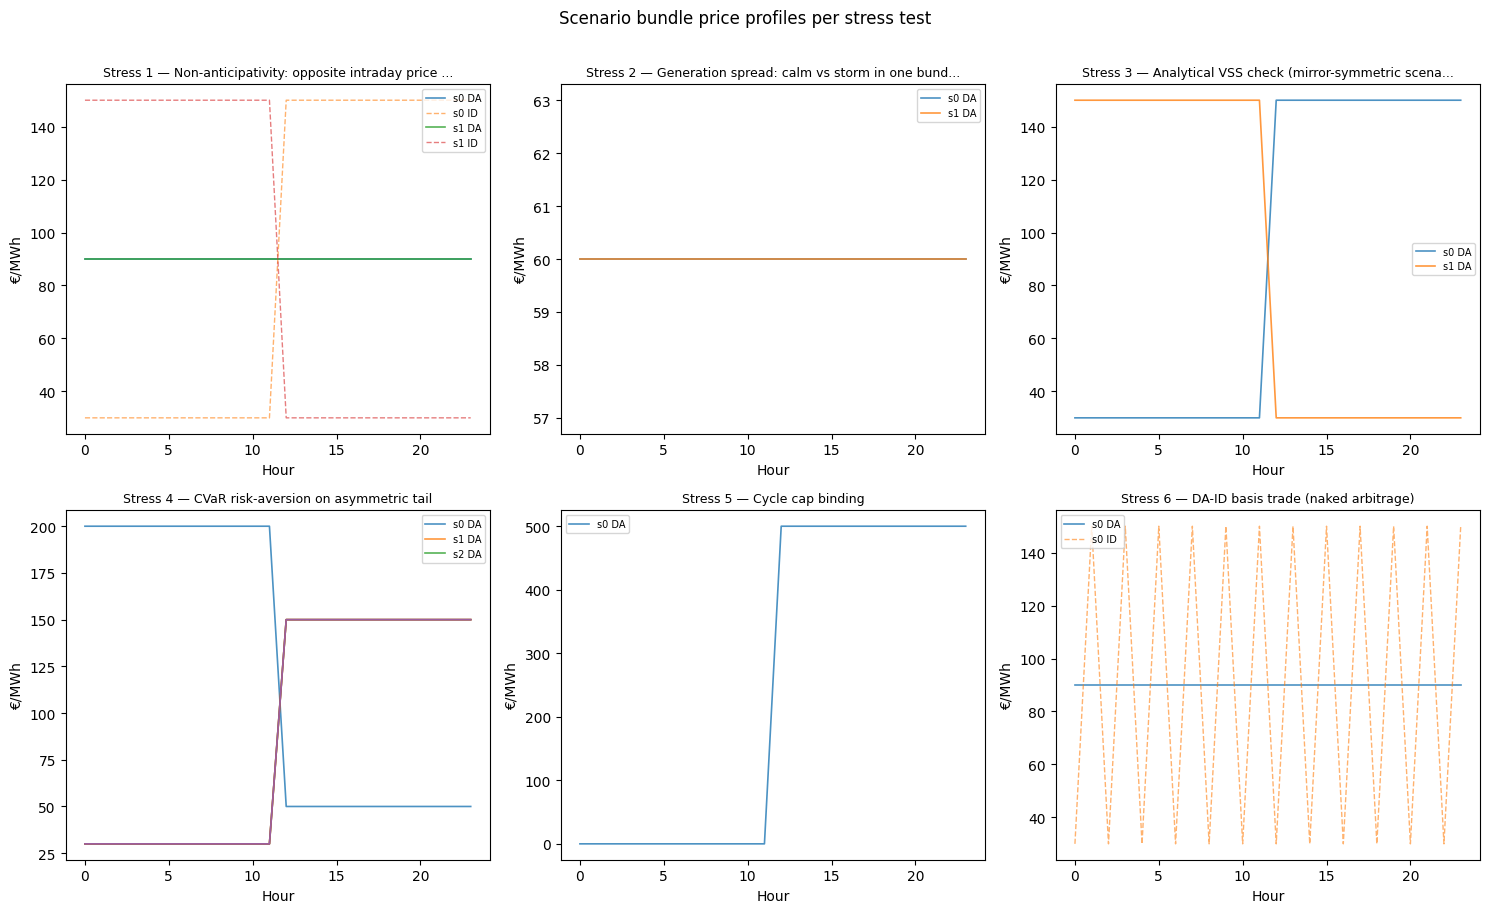

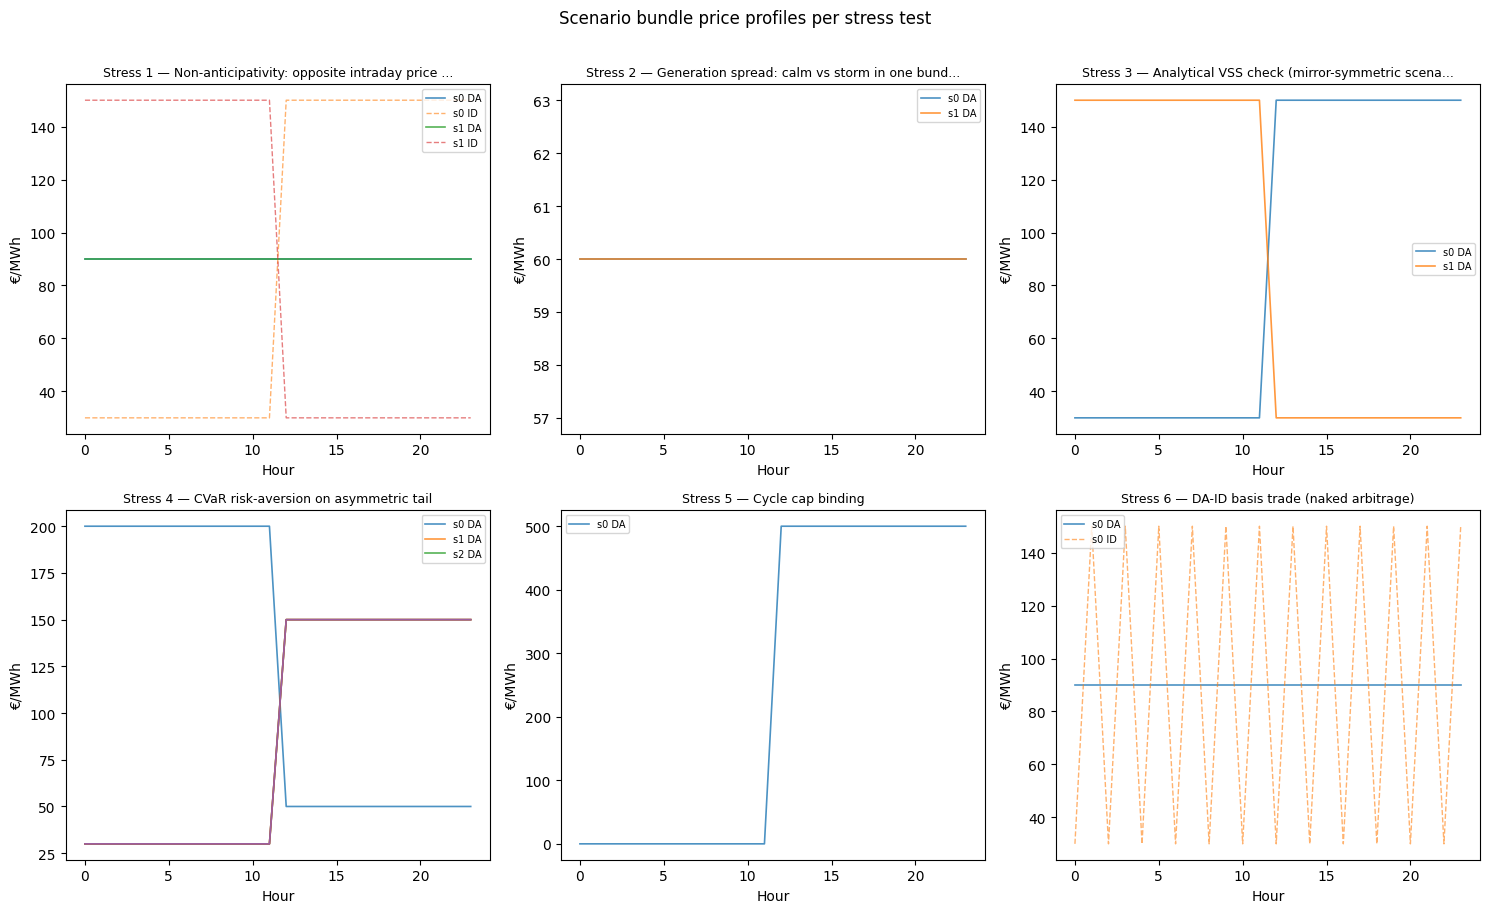

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), tight_layout=True)
for ax, r, idx in zip(axes.flat, results, range(1, len(results) + 1)):
    bundle = r.bundle
    hours = np.arange(bundle.da_prices.shape[1])
    for s in range(bundle.n_scenarios):
        ax.plot(hours, bundle.da_prices[s], lw=1.2, alpha=0.8, label=f's{s} DA' if s < 3 else None)
        if not np.allclose(bundle.id_prices[s], bundle.da_prices[s]):
            ax.plot(hours, bundle.id_prices[s], lw=1.0, alpha=0.6, ls='--', label=f's{s} ID' if s < 3 else None)
    ax.set_title(r.name[:55] + ("..." if len(r.name) > 55 else ""), fontsize=9)
    ax.set_xlabel('Hour')
    ax.set_ylabel('€/MWh')
    ax.legend(fontsize=7, loc='best')
fig.suptitle('Scenario bundle price profiles per stress test', y=1.01, fontsize=12)
fig


## Overall Verdict

If all three sections (5 sanity + 8 edge + 6 stochastic stress) pass, the MILP is validated for:

- Single-scenario deterministic profit maximisation (sanity)
- Boundary economic regimes (edge)
- Two-stage stochastic structure: non-anticipativity, recourse, VSS/EEV/EVPI computation, CVaR, cycle cap, and basis arbitrage (stress)

A failing stress test indicates the stochastic machinery is unreliable for that regime and the model should not be deployed for that use case without further fixes.